In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import time
import datetime
import os, sys, re
from IPython.display import display

sys.path.insert(1, r"C:\home\admin2\webapp_2\postprocess")


from importlib import reload

import core_post_processing_functions as cf
reload(cf)

<module 'core_post_processing_functions' from '/home/admin2/webapp_2/postprocess/core_post_processing_functions.py'>

In [13]:
# Try pulling agate data from webapp
rwb_pull = cf.rwb_fetch_data(regex='tt007', regex_col='DIE_ID')

Looking at table rwb_db_3
Fetching tt007 regular expression filter on RWB column DIE_ID
Data pulled from rwb_db_3
Pull successful


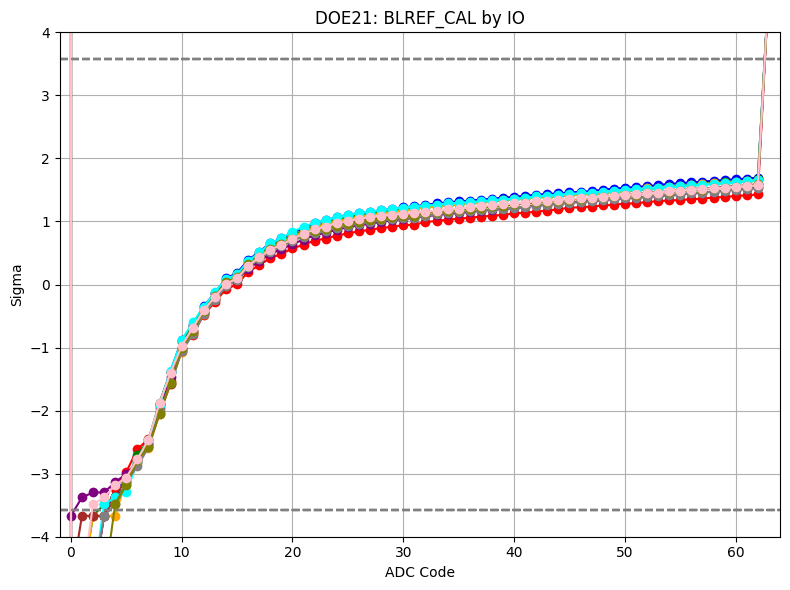

In [16]:
rwb_plot = rwb_pull.loc[rwb_pull.TEST_NAME.str.contains('post-form')&(rwb_pull.MACRO==0) & rwb_pull.TEST_START_DATETIME.str.contains('2025_06_27-15_57_38')]
cf.rwb_groupby_level_nqplot(rwb_plot, overlay_col='IO', legend=False, title=f'DOE21: BLREF_CAL by IO')

In [18]:
rwb_mean = cf.rwb_calc_io_mean(rwb_plot, groupby_cols=['TEST_NAME'])
display(rwb_mean[['TEST_NAME','LEVEL_01_XPOINT_PPM','LEVEL_12_XPOINT_PPM','LEVEL_23_XPOINT_PPM']])

/home/admin2/webapp_2/postprocess/core_post_processing_functions.py:2617: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  contains_ecc = rwb.TEST_NAME.str.contains('(ECC|ecc)', na=True).any() # Assume NaN is ECC pattern (conservative)


,TEST_NAME,LEVEL_01_XPOINT_PPM,LEVEL_12_XPOINT_PPM,LEVEL_23_XPOINT_PPM
0,post-form,12.208522,1000000.0,1000000.0
